# Surface Heat Flux

In [18]:
# packages for data processing
import numpy as np
import pandas as pd
import xarray as xr
from xmitgcm import open_mdsdataset
import gsw as gsw

# packages for plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go # interactive/3D plotting
import plotly.express as px
import cmocean.cm as cmo # ocean colormaps

# my own plotting functions
from plotting_functions import *

# technical packages
import warnings

## Load Surface Diagnostics & Output

In [31]:
model_run = "MSL007"
delta_t = 4 # time step in seconsurfDiag
output_dir = "../../MITgcm/so_plumes/" + model_run

# surpress the xmitgcm warning about future changes with timedelta
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)

    # diagnostic dataset
    surfDiag = open_mdsdataset(output_dir, prefix = ['surfDiag'], delta_t = delta_t, geometry = "cartesian")

    # output dataset
    ds = open_mdsdataset(output_dir, prefix = ['Eta', 'U', 'W', 'T', 'V', 'S', 'PH'], delta_t = delta_t, geometry = "cartesian")

## Heat Fluxes

- TFLUX: "total heat flux (match heat-content variations), >0 increases theta" -> this corresponds to the actual change in temperature
- surForcT: "model surface forcing for Temperature, >0 increases theta" -> what we set as forcing
- oceQnet: "net surface heat flux into the ocean (+=down), >0 increases theta" -> looks like oceQnet = surfForcT in our setting

Difference between surForcT and TFLUX corresponds to heat loss that would drive into ice formation.






## Surface Animation

In [20]:
# TFLUX
animation = False
if animation:
    fig = surface_animation(surfDiag, var='TFLUX', model_run=model_run, time_dim='time', x_dim='XC', y_dim='YC', colorscale="thermal")
    filename = "surface_animation_" + model_run + "_TFLUX" + ".html"
    fig.write_html(filename)
    # fig.show(renderer="browser") # this works in VScode, but not in Jupyterhub

### Surface Snapshot

In [4]:
surfDiag.XC

<xarray.DataArray 'XC' (XC: 594)> Size: 2kB
array([2.000e+00, 6.000e+00, 1.000e+01, ..., 2.366e+03, 2.370e+03, 2.374e+03],
      shape=(594,), dtype='>f4')
Coordinates:
  * XC       (XC) >f4 2kB 2.0 6.0 10.0 14.0 ... 2.366e+03 2.37e+03 2.374e+03
Attributes:
    standard_name:  plane_x_coordinate
    long_name:      x coordinate
    units:          m
    coordinate:     YC XC
    axis:           X

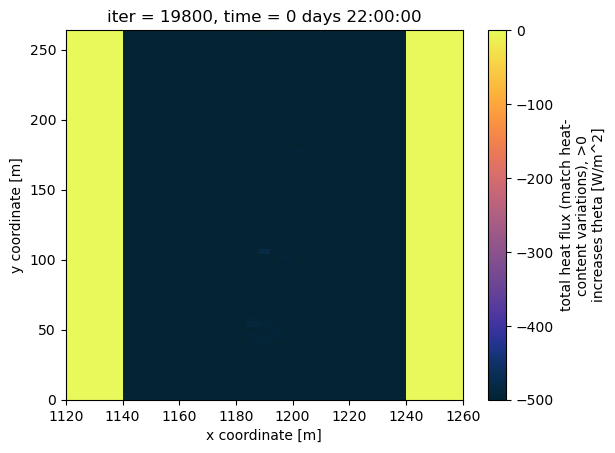

In [12]:
t = 10 #surfDiag.time[10]#
xmin = 280 # needs to be a multiple of 4 +2
xmax = 315 # needs to be a multiple of 4 +2
surfDiag.TFLUX.isel(time=t, XC=slice(xmin, xmax)).plot(x="XC", y="YC", cmap=cmo.thermal)

## Line Plot

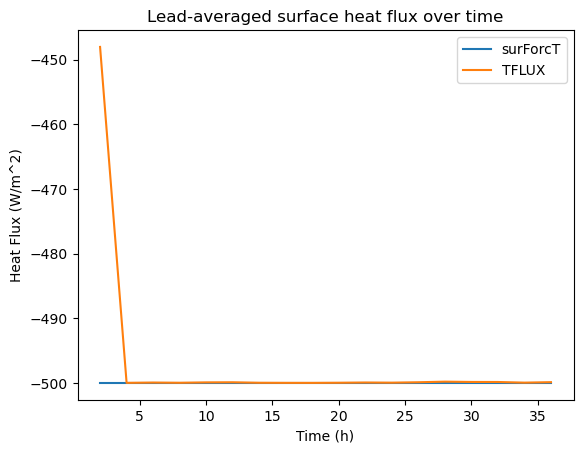

In [49]:
# lead-spatially averaged TFLUX over time
surfDiag_lead = surfDiag.isel(XC=slice(285, 310)) # or .sel with slice(1142, 1238)
surfDiag_lead_mean = surfDiag_lead.mean(dim = ["XC", "YC"])

# plt.plot(surfDiag_lead_mean.time/(60*60*1e9), surfDiag_lead_mean.oceQnet, label = "oceQnet")
plt.plot(surfDiag_lead_mean.time/(60*60*1e9), surfDiag_lead_mean.surForcT, label = "surForcT")
plt.plot(surfDiag_lead_mean.time/(60*60*1e9), surfDiag_lead_mean.TFLUX, label = "TFLUX")


# plt.ylim(-510, -400)

plt.ylabel("Heat Flux (W/m^2)")
plt.xlabel("Time (h)")
plt.title("Lead-averaged surface heat flux over time")
plt.legend()

## Lead Surface Mean Temperature

Text(0.5, 1.0, 'Lead-averaged surface temperature')

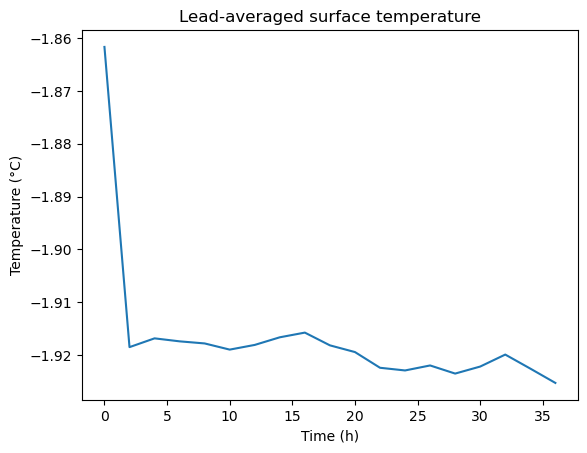

In [42]:
T_lead_surf = ds.T.isel(XC=slice(285, 310), Z=0)
T_lead_surf_mean = T_lead_surf.mean(dim = ["XC", "YC"])

plt.plot(T_lead_surf_mean.time/(60*60*1e9), T_lead_surf_mean)

plt.ylabel("Temperature (°C)")
plt.xlabel("Time (h)")
plt.title("Lead-averaged surface temperature")


## Freezing

When the surface temperature hits the freezing poinit, all remaining heat loss causes ice formation. We get this excess heat loss from the difference between `surForcT` and `TFLUX`. We want to estimate how much (virtual) ice is formed. From this, we can then estimate a realistic salt flux (from the brine rejection). 

Let's look at
- the total amount of ice formed per square-meter
- the instantanous rate of ice formation -> the salt flux due to the brine rejection